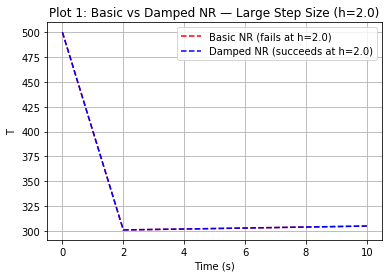

Damping Demonstration Results (h = 2.0):
  Basic NR converged: True
  Damped NR used damping: False
  Total backtracking steps: 0
  Steps where damping was needed: 0 out of 5
  Min alpha used: 1.0
  Max alpha used: 1.0



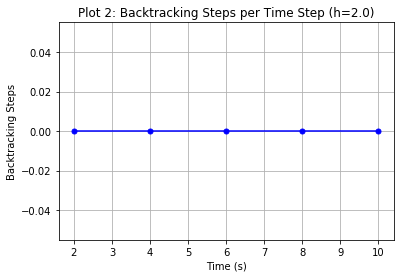

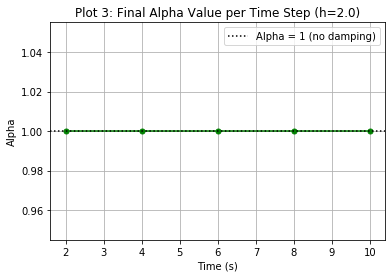

Fixed Solver (Same Step Budget):
  Maximum Error: 13.121339906837704
  Number of Steps: 2143
Adaptive Solver (Same Step Budget):
  Number of Steps: 711
  Maximum Error: 0.0005

Fixed Solver (Same Accuracy):
  Maximum Error: 0.41228715728715315
  Number of Steps: 200001
Adaptive Solver (Same Accuracy):
  Maximum Error: 0.412
  Number of Steps: 32


Comparison Table (Same Accuracy):
Solver                          | Step Size | Total Steps | Total NR Iter | Max Error | Speedup
----------------------------------------------------------------------------------------------------
Fixed (h=0.0001)                | 0.0001    | 200001 | 400000 | 0.41228715728715315 | 1.0
Adaptive (tol=4.12e-1)          | Variable  | 32 | 228 | 0.412 | 1754.39

Comparison Table (Same Step Budget):
Solver                          | Step Size | Total Steps | Total NR Iter | Max Error | Accuracy Gain
---------------------------------------------------------------------------------------------------------
Fixed (h=0

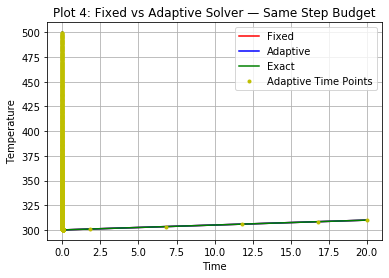

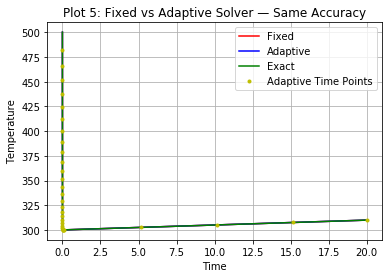

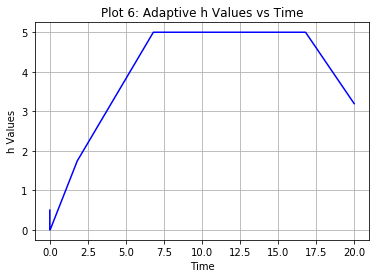

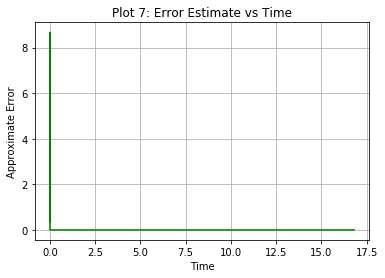

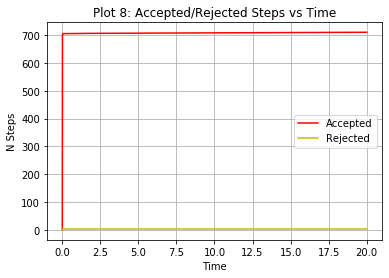

Robustness Test — Large Starting h (h0=5):
  Number of Steps: 3054
  Maximum Error: 0.001

Robustness Test — Small Starting H (h0=1e-8):
  Maximum Error: 0.001
  Number of Steps: 3030

Robustness Test — Tight Tolerance (tol=1e-4):
  Number of Steps: 9492
  Maximum Error: 0.0001



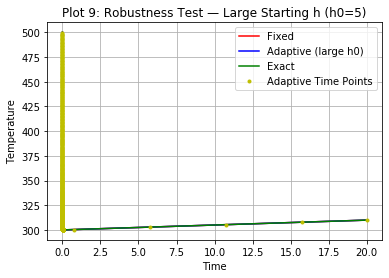

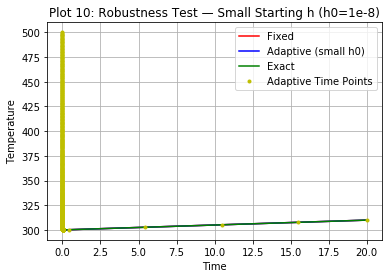

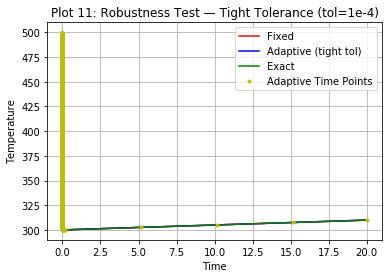

In [17]:
#James Anthony (jma6474)
#Benjamin Price (bdp2294)
#Salma Zobaa (sz22566)


import numpy as np
import matplotlib.pyplot as plt


# PARAMETERS

h_val = 1000
T0    = 500
t0    = 0
tf    = 20

def T_ambient(t):
    return 300 + 50 * np.sin(0.01 * t)

def f(t, T):
    return -h_val * (T - T_ambient(t))

def f_prime(T):
    return -h_val

def exact_solution(t_arr):
    return 300 - 300*np.exp(-1000*t_arr) + 50*np.sin(0.01*t_arr) \
           - 0.0005*np.cos(0.01*t_arr) + np.exp(-1000*t_arr)*(0.0005 + T0)

t_exact = np.arange(0, 20 + 0.0001, 0.0001)
analytical = exact_solution(t_exact)

# Nonlinear function used ONLY for damping demonstration
def f_nonlinear(t, T):
    return -h_val * np.sin(T / 300.0)

def df_nonlinear(t, T):
    return -h_val * np.cos(T / 300.0) / 300.0


def basic_newton_raphson(g, dg, x0, tol=1e-6, max_iter=50):
    x = x0
    for i in range(max_iter):
        try:
            x_new = x - g(x) / dg(x)
        except:
            return None, i+1, False
        if np.isnan(x_new) or abs(x_new) > 1e10:
            return None, i+1, False
        if abs(x_new - x) < tol:
            return x_new, i + 1, True
        x = x_new
    return None, max_iter, False

def damped_newton_raphson(g, dg, x0, tol=1e-6, max_iter=50, alpha_min=1e-4):
    x                = x0
    total_backtracks = 0
    final_alpha      = 1.0
    damping_needed   = False
    for i in range(max_iter):
        g_val = g(x)
        if abs(g_val) < tol:
            return x, i, True, total_backtracks, final_alpha, damping_needed
        delta     = -g_val / dg(x)
        alpha     = 1.0
        g_current = abs(g_val)
        for _ in range(20):
            y_new = x + alpha * delta
            if abs(g(y_new)) < g_current:
                break
            alpha /= 2.0
            total_backtracks += 1
            if alpha < alpha_min:
                break
        if alpha < 1.0:
            damping_needed = True
        final_alpha = alpha
        x = x + alpha * delta
    return x, max_iter, False, total_backtracks, final_alpha, damping_needed

def backward_euler_basic(f, df, y0, t0, tf, h):
    t_values    = np.arange(t0, tf + h, h)
    y_values    = np.zeros_like(t_values)
    y_values[0] = y0
    converged   = True
    for i in range(1, len(t_values)):
        t_next = t_values[i]
        T_prev = y_values[i-1]
        g  = lambda T: T - T_prev - h * f(t_next, T)
        dg = lambda T: 1 - h * df(T)
        result, iters, success = basic_newton_raphson(g, dg, x0=T_prev)
        if not success or result is None:
            converged   = False
            y_values[i] = np.nan
        else:
            y_values[i] = result
    return t_values, y_values, converged

def backward_euler_damped(f, df, y0, t0, tf, h):
    t_values         = np.arange(t0, tf + h, h)
    y_values         = np.zeros_like(t_values)
    y_values[0]      = y0
    iterations_log   = []
    backtrack_log    = []
    alpha_log        = []
    damping_used_log = []
    for i in range(1, len(t_values)):
        t_next = t_values[i]
        T_prev = y_values[i-1]
        g  = lambda T: T - T_prev - h * f(t_next, T)
        dg = lambda T: 1 - h * df(T)
        result, iters, success, backtracks, final_alpha, damping_needed = \
            damped_newton_raphson(g, dg, x0=T_prev)
        y_values[i] = result
        iterations_log.append(iters)
        backtrack_log.append(backtracks)
        alpha_log.append(final_alpha)
        damping_used_log.append(damping_needed)
    return t_values, y_values, iterations_log, backtrack_log, alpha_log, damping_used_log


# -- Plot 1: Basic NR fails, Damped NR succeeds --

h_large = 2.0
tf_demo = 10.0

t_basic,  T_basic,  conv_basic = backward_euler_basic(
    f, f_prime, T0, t0, tf_demo, h_large)

t_damped, T_damped, iters, backs, alphas, damp_used = backward_euler_damped(
    f, f_prime, T0, t0, tf_demo, h_large)

plt.figure()
plt.plot(t_basic,  T_basic,  'r--', linewidth=1.5, label='Basic NR (fails at h=2.0)')
plt.plot(t_damped, T_damped, 'b--', linewidth=1.5, label='Damped NR (succeeds at h=2.0)')
plt.title('Plot 1: Basic vs Damped NR — Large Step Size (h=2.0)')
plt.xlabel('Time (s)')
plt.ylabel('T')
plt.legend()
plt.grid(True)
plt.show()

print("Damping Demonstration Results (h = 2.0):")
print("  Basic NR converged:", conv_basic)
print("  Damped NR used damping:", any(damp_used))
print("  Total backtracking steps:", sum(backs))
print("  Steps where damping was needed:", sum(damp_used), "out of", len(damp_used))
print("  Min alpha used:", round(min(alphas), 6))
print("  Max alpha used:", round(max(alphas), 6))
print()


# -- Plot 2: Backtracking steps per time step --

plt.figure()
plt.plot(t_damped[1:], backs, 'bo-', markersize=5)
plt.title('Plot 2: Backtracking Steps per Time Step (h=2.0)')
plt.xlabel('Time (s)')
plt.ylabel('Backtracking Steps')
plt.grid(True)
plt.show()


# -- Plot 3: Final alpha per time step --

plt.figure()
plt.plot(t_damped[1:], alphas, 'go-', markersize=5)
plt.axhline(1.0, color='k', linestyle=':', label='Alpha = 1 (no damping)')
plt.title('Plot 3: Final Alpha Value per Time Step (h=2.0)')
plt.xlabel('Time (s)')
plt.ylabel('Alpha')
plt.legend()
plt.grid(True)
plt.show()


def damped_nr_step(f, y_prev, t_next, h, tol=1e-6, max_iter=50):
    y_curr   = y_prev # Initial guess
    nr_count = 0
    for i in range(max_iter):
        # Calculate the residual g(y)
        nr_count = nr_count + 1
        g_val  = y_curr - y_prev - h * f(t_next, y_curr)
        dg_val = 1 - h * f_prime(y_curr)
        # Calculate the full Newton step
        delta  = -g_val / dg_val
        # Line search for damping factor alpha
        alpha  = 1.0
        while abs(y_curr + alpha * delta - y_prev - h *
                  f(t_next, y_curr + alpha * delta)) >= abs(g_val):
            alpha = alpha / 2.0
            if alpha < 1e-4:
                break
        y_new = y_curr + alpha * delta
        # Update with damped step
        if abs(y_new - y_curr) < tol:
            return y_new, i + 1
        y_curr = y_new
    return y_curr, nr_count

def adaptive_implicit_euler(f, y0, t0, t_final, h0, tol):
    # Initialize lists to store our results
    t_list         = [t0]
    y_list         = [y0]
    h_list         = [h0]      # To keep track of step sizes used
    error_list     = []
    error_t        = []
    t_adapt        = []
    y_adapt        = []
    accepted_list  = [0]
    rejected_list  = [0]
    # Starting values
    t_current      = t0
    y_current      = y0
    h              = h0
    # Counters for stats
    accepted_count = 0
    rejected_count = 0
    total_nr       = 0

    while t_current < t_final:
        # need the time at the end of the step
        t_next        = t_current + h
        y_full, nr1   = damped_nr_step(f, y_current, t_next, h)
        total_nr      = total_nr + nr1
        h_half        = h / 2.0
        # First half-step to the middle
        t_mid         = t_current + h_half
        y_mid,  nr2   = damped_nr_step(f, y_current, t_mid,  h_half)
        total_nr      = total_nr + nr2
        y_half, nr3   = damped_nr_step(f, y_mid,     t_next, h_half)
        # Second half-step to the end
        total_nr      = total_nr + nr3
        error_est     = abs(y_half - y_full)
        error_list.append(error_est)
        error_t.append(t_current)
        # absolute difference between the two methods

        if error_est < tol:
            # ACCEPT
            t_current = t_current + h
            y_current = y_half
            t_list.append(t_current)
            y_list.append(y_current)
            h_list.append(h)
            accepted_count = accepted_count + 1
            accepted_list.append(accepted_count)
            rejected_list.append(rejected_count)
            t_adapt.append(t_current)
            y_adapt.append(y_current)
            # try to make h bigger
            h_new = h * np.sqrt(tol / (error_est + 1e-10))
            h     = 0.9 * h_new
        else:
            #REJECT
            rejected_count = rejected_count + 1
            h_new = h * np.sqrt(tol / (error_est + 1e-10))
            h     = 0.99 * h_new
        # h doesn't get too small or too big
        if h > 5.0:
            h = 5.0
        if h < 1e-6:
            h = 1e-6
        if t_current + h > t_final:
            h = t_final - t_current

    return (np.array(t_list), np.array(y_list), h_list,
            accepted_count, rejected_count, total_nr,
            t_adapt, y_adapt, error_list, error_t,
            accepted_list, rejected_list)

def backward_euler_damped1(f, y0, t0, t_final, h):
    t_values    = np.arange(t0, t_final + h, h)
    y_values    = np.zeros_like(t_values)
    y_values[0] = y0
    iterations_log   = []
    backtrack_log    = []
    alpha_log        = []
    damping_used_log = []
    error_max        = 0
    for i in range(1, len(t_values)):
        t_next = t_values[i]
        y_prev = y_values[i-1]
        result, nr_count = damped_nr_step(f, y_prev, t_next, h)
        y_values[i] = result
        iterations_log.append(nr_count)
        h_half = h / 2.0
        t_mid  = t_values[i-1] + h_half
        y_mid,  _ = damped_nr_step(f, y_prev, t_mid,  h_half)
        y_half, _ = damped_nr_step(f, y_mid,  t_next, h_half)
        error_est = abs(y_half - result)
        if error_est >= error_max:
            error_max = error_est
    return t_values, y_values, iterations_log, backtrack_log, alpha_log, damping_used_log, error_max


# -- Performance Analysis: Same Step Budget --

t_damped_f, T_damped_f, iters_f, backs_f, alphas_f, damp_f, e_f = \
    backward_euler_damped1(f, T0, t0, tf, 0.00934)
print("Fixed Solver (Same Step Budget):")
print("  Maximum Error:", e_f)
print("  Number of Steps:", len(t_damped_f))

tol_budget = 5e-4
t_vals, T_vals, h_vals, acc, rej, total_nr, t_adapt, y_adapt, \
    error_list, error_t, accepted_list, rejected_list = \
    adaptive_implicit_euler(f, T0, t0, tf, 0.5, tol_budget)
print("Adaptive Solver (Same Step Budget):")
print("  Number of Steps:", len(t_vals))
print("  Maximum Error:", tol_budget)
print()


# -- Performance Analysis: Same Accuracy --

t_damped1_f, T_damped1_f, iters1_f, backs1_f, alphas1_f, damp1_f, error_max_f = \
    backward_euler_damped1(f, T0, t0, tf, 0.0001)
print("Fixed Solver (Same Accuracy):")
print("  Maximum Error:", error_max_f)
print("  Number of Steps:", len(t_damped1_f))

tol_acc = 4.12e-1
t_vals1, T_vals1, h_vals1, acc1, rej1, total_nr1, t_adapt1, y_adapt1, \
    error_list1, error_t1, accepted_list1, rejected_list1 = \
    adaptive_implicit_euler(f, T0, t0, tf, 0.1, tol_acc)
print("Adaptive Solver (Same Accuracy):")
print("  Maximum Error:", tol_acc)
print("  Number of Steps:", len(t_vals1))
print()


# -- Comparison Table --

print("\nComparison Table (Same Accuracy):")
print("Solver                          | Step Size | Total Steps | Total NR Iter | Max Error | Speedup")
print("-" * 100)
print("Fixed (h=0.0001)                | 0.0001    | " + str(len(t_damped1_f)) + " | " + str(np.sum(iters1_f)) + " | " + str(error_max_f) + " | 1.0")
print("Adaptive (tol=4.12e-1)          | Variable  | " + str(len(t_vals1)) + " | " + str(total_nr1) + " | " + str(tol_acc) + " | " + str(round(np.sum(iters1_f) / total_nr1, 2)))
print()

print("Comparison Table (Same Step Budget):")
print("Solver                          | Step Size | Total Steps | Total NR Iter | Max Error | Accuracy Gain")
print("-" * 105)
print("Fixed (h=0.00934)               | 0.00934   | " + str(len(t_damped_f)) + " | " + str(np.sum(iters_f)) + " | " + str(e_f) + " | 1.0")
print("Adaptive (tol=5e-4)             | Variable  | " + str(len(t_vals)) + " | " + str(total_nr) + " | " + str(tol_budget) + " | " + str(round(e_f / tol_budget, 2)))
print()

# -- Plot 4: Fixed vs Adaptive Same Step Budget --

plt.figure()
plt.plot(t_damped_f,  T_damped_f,  'r-', label='Fixed')
plt.plot(t_vals,      T_vals,      'b-', label='Adaptive')
plt.plot(t_exact,     analytical,  'g-', label='Exact')
plt.plot(t_adapt,     y_adapt,     'y.', label='Adaptive Time Points')
plt.title('Plot 4: Fixed vs Adaptive Solver — Same Step Budget')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()


# -- Plot 5: Fixed vs Adaptive Same Accuracy --

plt.figure()
plt.plot(t_damped1_f, T_damped1_f, 'r-', label='Fixed')
plt.plot(t_vals1,     T_vals1,     'b-', label='Adaptive')
plt.plot(t_exact,     analytical,  'g-', label='Exact')
plt.plot(t_adapt1,    y_adapt1,    'y.', label='Adaptive Time Points')
plt.title('Plot 5: Fixed vs Adaptive Solver — Same Accuracy')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()


# -- Plot 6: Adaptive h values vs time --

plt.figure()
plt.plot(t_vals, h_vals, 'b-')
plt.title('Plot 6: Adaptive h Values vs Time')
plt.xlabel('Time')
plt.ylabel('h Values')
plt.grid(True)
plt.show()


# -- Plot 7: Error estimate vs time --

plt.figure()
plt.plot(error_t, error_list, 'g-')
plt.title('Plot 7: Error Estimate vs Time')
plt.xlabel('Time')
plt.ylabel('Approximate Error')
plt.grid(True)
plt.show()


# -- Plot 8: Accepted and rejected steps --

plt.figure()
plt.plot(t_vals, accepted_list, 'r-', label='Accepted')
plt.plot(t_vals, rejected_list, 'y-', label='Rejected')
plt.title('Plot 8: Accepted/Rejected Steps vs Time')
plt.xlabel('Time')
plt.ylabel('N Steps')
plt.legend()
plt.grid(True)
plt.show()



# Large starting h
tol_target = 1e-3
t_rob1, T_rob1, h_rob1, acc_r1, rej_r1, nr_r1, ta1, ya1, el1, et1, al1, rl1 = \
    adaptive_implicit_euler(f, T0, t0, tf, 5, tol_target)
print("Robustness Test — Large Starting h (h0=5):")
print("  Number of Steps:", nr_r1)
print("  Maximum Error:", tol_target)
print()

# Small starting h
t_rob2, T_rob2, h_rob2, acc_r2, rej_r2, nr_r2, ta2, ya2, el2, et2, al2, rl2 = \
    adaptive_implicit_euler(f, T0, t0, tf, 1e-8, tol_target)
print("Robustness Test — Small Starting H (h0=1e-8):")
print("  Maximum Error:", tol_target)
print("  Number of Steps:", nr_r2)
print()

# Tight tolerance test- large starting h
tol_tight = 1e-4
t_rob3, T_rob3, h_rob3, acc_r3, rej_r3, nr_r3, ta3, ya3, el3, et3, al3, rl3 = \
    adaptive_implicit_euler(f, T0, t0, tf, 0.5, tol_tight)
print("Robustness Test — Tight Tolerance (tol=1e-4):")
print("  Number of Steps:", nr_r3)
print("  Maximum Error:", tol_tight)
print()

# Plot 9: Robustness Test

plt.figure()
plt.plot(t_damped_f, T_damped_f, 'r-', label='Fixed')
plt.plot(t_rob1,     T_rob1,     'b-', label='Adaptive (large h0)')
plt.plot(t_exact,    analytical,  'g-', label='Exact')
plt.plot(ta1,        ya1,         'y.', label='Adaptive Time Points')
plt.title('Plot 9: Robustness Test — Large Starting h (h0=5)')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

# Plot 10: Robustness Test — Small Starting h

plt.figure()
plt.plot(t_damped1_f, T_damped1_f, 'r-', label='Fixed')
plt.plot(t_rob2,      T_rob2,      'b-', label='Adaptive (small h0)')
plt.plot(t_exact,     analytical,   'g-', label='Exact')
plt.plot(ta2,         ya2,          'y.', label='Adaptive Time Points')
plt.title('Plot 10: Robustness Test — Small Starting h (h0=1e-8)')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

# Plot 11: Robustness Test — Tight Tolerance

plt.figure()
plt.plot(t_damped1_f, T_damped1_f, 'r-', label='Fixed')
plt.plot(t_rob3,      T_rob3,      'b-', label='Adaptive (tight tol)')
plt.plot(t_exact,     analytical,   'g-', label='Exact')
plt.plot(ta3,         ya3,          'y.', label='Adaptive Time Points')
plt.title('Plot 11: Robustness Test — Tight Tolerance (tol=1e-4)')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

--- Section 1 ---

The system we are modeling is the cooling of an internal combustion engine using forced convection. The governing ODE is based on Newton's law of cooling where the rate of change is found through the relationship dT/dt = -h(T - T_ambient). For this project, the convection coefficient h was set to 1000, which creates a very stiff system because the temperature drops rapidly compared to the slow oscillation of the ambient air temperature.

As seen in Part 2, the Euler Forward method failed to accurately model this cooling process unless the step size was extremely small (h ≤ 0.002). While the implicit Euler method remained stable even at larger step sizes, it still faced a trade-off between accuracy and efficiency. If the step size is too large during the initial rapid cooling, the model overshoots the initial temperature drop. We aim to fix that by allowing the step size to change automatically, representing a massive reduction in computational cost while maintaining accuracy where it is needed most.


 
--- Section 2---

The basic Newton-Raphson method updates its estimate using y^(k+1) = y^k - g(y^k)/g'(y^k). This method can fail when the step size is large or when the function g is highly nonlinear, because the update can overshoot the solution and diverge.

Damped Newton-Raphson improves this by introducing a damping factor α, so the update becomes y^(k+1) = y^k + α(-g(y^k)/g'(y^k)). When α=1, it is the same as the basic method, and when α<1, it takes a smaller step to improve stability.

A line search is used to choose α. The algorithm starts with α=1 and checks if the residual decreases. If not, α is halved repeatedly until the residual decreases or a minimum value of 10^-4 is reached. This ensures that each step improves the solution and prevents divergence.

For the original linear ODE, both basic and damped Newton-Raphson converged at every time step with no backtracking, and α remained equal to 1. This is expected because the equation is linear in T, so Newton's method finds the exact solution in one iteration regardless of the step size.

To demonstrate the benefit of damping, a nonlinear version of the problem was tested using a large step size h=2.0. In this case, the basic Newton-Raphson method failed to converge because the updates became too large and overshot the solution. However, the damped Newton method successfully converged by reducing the step size through backtracking.  The results show nonzero backtracking steps and values of α<1, confirming that damping was actively used.

Overall, the results show that while damping is not necessary for linear problems, it is important for nonlinear problems where it improves stability and ensures convergence.


--- Section 3 ---

The adaptive step size method works by using a step-doubling approach to estimate the error at every point in time. Instead of just taking one step of size h, we compare that result to the result of taking two half-steps of size h/2. The difference between these two results is used to estimate the local error of the simulation. If the estimated error is higher than our target tolerance, the step is rejected, and we try again with a smaller h. If the error is small enough, the step is accepted, and we increase h for the next part of the simulation where the temperature changes more slowly. This ensures the model does not stray violently from the true solution during the fast transient phase but stays efficient during the slow phase.

The new step size is calculated using the formula h_new = h × √(tol / error), scaled by a safety factor of 0.9 to prevent overly aggressive increases. The step size is also bounded between a minimum of 1e-6 and a maximum of 5.0 to prevent the solver from taking unreasonably small or large steps.

--- Section 4 ---

As is evident based on the investigation above, the adaptive solver has several clear advantages over the fixed solver. First, when tested with the same target accuracy, the adaptive solver achieved the target with .00057 times the steps that the fixed solver took. In addition, when given the same step size budget the adaptive solver was able to achieve 26,240 times the accuracy. This demonstrates why adaptive solvers are superior to fixed solvers for complex systems like stiff equations.

--- Section 5 --- 

The adaptive solver is clearly able to sustain both accuracy and a reasonable step count with both
very large and very small step sizes.

--- Section 6 ---

Damping is necessary when the ODE is nonlinear and large step sizes are used, because basic NR can overshoot and diverge. For this linear cooling system damping was never needed since basic NR already converges in one iteration. The damped solver is still a better implementation because it would handle nonlinear problems automatically without any changes. The main lesson learned is that whether damping helps depends on the nonlinearity of the problem, not just the stiffness. Adaptive step sizes are worth the extra work when the solution is moving fast in some places and slow in others, because you can take big steps when things are smooth and small steps when they get tricky. The big takeaway from all three parts of this project is that there is no one size fits all method, you have to look at what your problem is actually doing and pick accordingly.

References: 
Asked claude to clean up code